In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import stan
import seaborn as sns
from pathlib import Path
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load PCF curves and peak table
pcf_all = pd.read_csv('processed_data/pcf_curve_ALL.csv')
peaks = pd.read_csv('processed_data/pcf_peak_table_ALL.csv')

pcf_all['date'] = pd.to_datetime(pcf_all['date'])
peaks['date'] = pd.to_datetime(peaks['date'])

pcf_all.head()

,r,s,g,N_eff,lek_id,data_label,date,n_points,nn_median
0,0.000000,0.000000,inf,0.0,TalChhapar_TC,12OCT,2012-10-01,162,15.880343
1,0.319203,0.020101,1.996531e-14,0.0,TalChhapar_TC,12OCT,2012-10-01,162,15.880343
2,0.638406,0.040201,1.189931e-14,0.0,TalChhapar_TC,12OCT,2012-10-01,162,15.880343
3,0.957609,0.060302,5.180427e-15,0.0,TalChhapar_TC,12OCT,2012-10-01,162,15.880343
4,1.276812,0.080402,7.536469e-15,0.0,TalChhapar_TC,12OCT,2012-10-01,162,15.880343


In [4]:
## Create consistent integer encodings for sites
site_lookup = {lek: i+1 for i,lek in enumerate(sorted(pcf_all['lek_id'].unique()))}
unique_dates = sorted(pcf_all['date'].unique())

pcf_all['site_id'] = pcf_all['lek_id'].map(site_lookup)
peaks['site_id'] = peaks['lek_id'].map(site_lookup)

In [5]:
## Isolate a row for each PCF curve to count peaks
cols = ['lek_id', 'site_id', 'date', 'n_points']
curves_base = pcf_all[cols].drop_duplicates().sort_values(['lek_id', 'date']).reset_index(drop=True)

In [6]:
## For each curve (lek × date), get the peak-count category; curves with no detected peaks become 0
peaks_count = peaks.groupby(['lek_id', 'date'], as_index=False)['n_peaks'].max().rename(columns={'n_peaks': 'n_peaks'})
n_peaks_df = curves_base.merge(peaks_count, on=['lek_id', 'date'], how='left').assign(n_peaks=lambda d: d['n_peaks'].fillna(0).astype(int))

In [7]:
## Factor ordering + labels
lek_order = ['TalChhapar_TC', 'Velavadar_LEK1', 'Velavadar_LEK2']
lek_labels = {'TalChhapar_TC': 'Tal Chhapar', 'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2'}

n_peaks_df['lek_id'] = (pd.Categorical(n_peaks_df['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))

## Map site ID to lek labels
site_to_lek = n_peaks_df[['site_id', 'lek_id']].drop_duplicates().sort_values('site_id')
site_to_lek = dict(zip(site_to_lek['site_id'].astype(int), site_to_lek['lek_id']))

In [8]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

lek_labels_ordered = n_peaks_df['lek_id'].cat.categories.tolist()

In [9]:
## Serialise and centre the date / time
t0 = n_peaks_df['date'].min()
n_peaks_df['t_years'] = (n_peaks_df['date'] - t0).dt.days / 365.25
n_peaks_df['t_centred'] = n_peaks_df['t_years'] - n_peaks_df['t_years'].mean()

logN = np.log(n_peaks_df['n_points'])
n_peaks_df['logN_z'] = (logN - logN.mean()) / logN.std()

In [10]:
n_peaks_df.head()

,lek_id,site_id,date,n_points,n_peaks,t_years,t_centred,logN_z
0,Tal Chhapar,1,2012-10-01,162,3,0.000000,-5.443760,0.841368
1,Tal Chhapar,1,2014-02-01,193,2,1.336071,-4.107689,1.152652
2,Tal Chhapar,1,2015-11-01,127,3,3.082820,-2.360940,0.408632
3,Tal Chhapar,1,2015-12-01,106,3,3.164956,-2.278804,0.087297
4,Tal Chhapar,1,2018-01-01,241,2,5.251198,-0.192562,1.547516


### Model the **total effect** of site-ID and time on the number of PCF peaks

In [61]:
## Model the number of peaks for each lek
## Ordered logistic model: latent "structure" score per site and cutpoints define peak count categories
n_peaks_mod = """
data {
    int<lower=1> n_points;
    int<lower=1> n_sites;
    int<lower=2> max_peaks;

    array[n_points] int<lower=1,upper=n_sites> site_id;
    array[n_points] int<lower=1,upper=max_peaks> y;

    vector[n_points] t;
}

parameters {
    vector[n_sites] site_eff_raw;
    ordered[max_peaks-1] c;

    vector[n_sites] beta_t;
}

transformed parameters {
    vector[n_sites] alpha;
    alpha = site_eff_raw - mean(site_eff_raw);
}

model {
    site_eff_raw ~ normal(0, 1);
    c ~ normal(0, 2);
    beta_t ~ normal(0, 1);

    for (n in 1:n_points) {
        real eta = alpha[site_id[n]] + beta_t[site_id[n]]*t[n];
        y[n] ~ ordered_logistic(eta, c);
    }
}

generated quantities {
    real diff_T_V1 = alpha[1] - alpha[2];
    real diff_V1_V2 = alpha[2] - alpha[3];
    real diff_T_V2 = alpha[1] - alpha[3];

    array[n_sites] vector[max_peaks] p_site;

    for (s in 1:n_sites) {
        // calculated at t=0 which is okay because the variable is centred
        real eta = alpha[s];

        // cumulative probs: P(Y <= k)
        vector[max_peaks - 1] F;
        for (k in 1:(max_peaks - 1)) {
            F[k] = inv_logit(c[k] - eta);
        }

        // category probs from cumulative probs
        p_site[s][1] = F[1];
        for (k in 2:(max_peaks - 1)) {
            p_site[s][k] = F[k] - F[k - 1];
        }
        p_site[s][max_peaks] = 1 - F[max_peaks - 1];
    }

    array[n_points] int<lower=1, upper=max_peaks> y_rep;
    
    for (n in 1:n_points) {
        real eta = alpha[site_id[n]] + beta_t[site_id[n]]*t[n];
        y_rep[n] = ordered_logistic_rng(eta, c);
    }
}
"""

In [62]:
data_peaks = {
    'n_points': len(n_peaks_df),
    'n_sites': int(n_peaks_df['site_id'].nunique()),
    'max_peaks': 5,
    'site_id': n_peaks_df['site_id'].astype(int).to_numpy(),
    'y': n_peaks_df['n_peaks'].astype(int).to_numpy() + 1,
    't': n_peaks_df['t_centred'].astype(float).to_numpy()
}

posterior = stan.build(n_peaks_mod, data=data_peaks)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  10% (800/8000)
Sampling:  35% (2800/8000)
Sampling:  60% (4800/8000)
Sampling:  85% (6800/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 5.1e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.51 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is inf, but should be greater than the previous element, inf (in '/tmp/httpstan_eh8ywtgy/model_iogzepsh.stan', line 32, column 8 to column 40)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspeci

In [45]:
## Posterior distributions of latent structure on the leks at mean centred time
alpha = fit['alpha']
tal = alpha[0, :]
vel1 = alpha[1, :]
vel2 = alpha[2, :]

## Difference in latent structure between Tal Chhapar and the two Velavadar leks at mean centred time
delta1 = tal - vel1
delta2 = tal - vel2

In [46]:
## Probability of the Tal Chhapar lek having more structure
pr_v1 = (delta1 > 0).mean()
pr_v2 = (delta2 > 0).mean()

## Median + CI of difference in structure between the two locations
med_diff1 = np.median(delta1)
ci_diff1 = np.quantile(delta1, [0.025, 0.975])
med_diff2 = np.median(delta2)
ci_diff2 = np.quantile(delta2, [0.025, 0.975])

## Odds ratio of the median difference in structure
or_med1 = np.exp(med_diff1)
or_med2 = np.exp(med_diff2)

print(f'The probability of Tal Chhapar having more latent structure than the Velavadar leks is {pr_v1} and  {pr_v2} respectively')
print(f'The probability of curves having 2 or more peaks for Tal Chhapar and Velavadar leks is {fit["p_site"][:,2:,:].sum(1).mean(1)} respectively')
print(f'The cumulative odds ratios at mean centred time for Tal Chhapar relative to the Velavadar leks are {or_med1} and {or_med2}')

The probability of Tal Chhapar having more latent structure than the Velavadar leks is 0.949 and  0.9815 respectively
The probability of curves having 2 or more peaks for Tal Chhapar and Velavadar leks is [0.81425518 0.57691991 0.46391954] respectively
The cumulative odds ratios at mean centred time for Tal Chhapar relative to the Velavadar leks are 3.4409770487542253 and 5.7204149861254265


In [47]:
np.mean(fit['p_site'][:,2:].sum(1), axis=1)

array([0.81425518, 0.57691991, 0.46391954])

In [48]:
np.quantile(fit['p_site'][:,2:].sum(1), 0.025, axis=1)

array([0.6155816 , 0.30528692, 0.16900408])

In [49]:
np.quantile(fit['p_site'][:,2:].sum(1), 0.975, axis=1)

array([0.9392039 , 0.8185605 , 0.77259133])

In [50]:
## Empirical probability of each peak count category per lek (for plotting against posterior)
peak_categories = np.sort(n_peaks_df['n_peaks'].unique())

peaks_counts = n_peaks_df[['lek_id', 'date', 'n_peaks']].drop_duplicates().copy()
peak_proportions = peaks_counts.assign(n_peaks=lambda d: d['n_peaks'].astype(int)).groupby(['lek_id', 'n_peaks'], observed=False).size().rename('count').reset_index()
peak_proportions['prop'] = peak_proportions.groupby('lek_id', observed=False)['count'].transform(lambda x: x / x.sum())

In [51]:
n_sites_post, k_post, n_draws = fit['p_site'].shape
assert k_post == len(n_peaks_df['n_peaks'].unique()), f'p_site has {k_post} categories, expected {max_peaks}'

## Summarize posterior p_site per site × category
post_rows = []
for s in range(1, n_sites_post+1):
    for k in range(1, k_post+1):
        draws = fit['p_site'][s-1, k-1, :]
        post_rows.append({
            'site_id': s, 'lek_id': site_to_lek.get(s), 'n_peaks': k-1, 
            'mean': float(np.mean(draws)), 'lower': float(np.quantile(draws, 0.025)), 'upper': float(np.quantile(draws, 0.975))})
        
post = pd.DataFrame(post_rows)

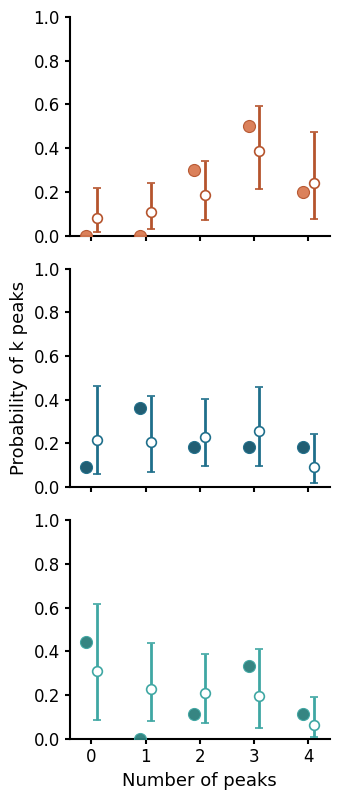

In [64]:
## Plot empirical category probabilities against posterior (mean ± 95% CI)
fig, axes = plt.subplots(3, 1, figsize=(3.5, 9), sharex=True)

x_offset = 0.1  # small dodge so empirical and posterior don't overlap

for ax, lek in zip(axes, lek_labels_ordered):
    empirical_data = peak_proportions[peak_proportions['lek_id'] == lek].sort_values('n_peaks')
    model_posteriors = post[post['lek_id'] == lek].sort_values('n_peaks')

    col_fill = fill_cols[str(lek)]
    col_point = point_cols[str(lek)]

    # Empirical proportions
    ax.scatter(empirical_data['n_peaks'] - x_offset, empirical_data['prop'], s=75, facecolor=col_point, edgecolor=col_fill,
               linewidth=0.8, alpha=0.95, zorder=4, label="Empirical" if ax is axes[0] else None)

    # Posterior summary (mean + 95% CI)
    ax.errorbar(model_posteriors['n_peaks'] + x_offset, model_posteriors['mean'],
                yerr=[model_posteriors['mean'] - model_posteriors['lower'], model_posteriors['upper'] - model_posteriors['mean']],
                fmt='o', markersize=7, mfc='white', mec=col_fill, mew=1.2, color=col_fill, ecolor=col_fill, elinewidth=2, 
                capsize=3, zorder=3, label="Posterior (mean ± 95% CI)" if ax is axes[0] else None)

    ax.set_xticks(peak_categories)
    ax.set_xlim(-0.4, peak_categories.max() + 0.4)
    ax.set_ylim(0, 1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

axes[2].set_xlabel('Number of peaks', fontsize=13)
axes[1].set_ylabel('Probability of k peaks', fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(out_dir/'mod_npeaks_structure.png', dpi=300, bbox_inches='tight')

In [66]:
n_points, n_draws = fit['y_rep'].shape

## Compute replicated proportions for each posterior draw
ppc_df = []

for draw in range(n_draws):
    rep = n_peaks_df[['lek_id']].copy()
    rep['n_peaks'] = fit['y_rep'][:,draw] - 1
    
    rep_props = rep.groupby(['lek_id', 'n_peaks'], observed=False).size().rename('count').reset_index()
    rep_props['proportion'] = rep_props.groupby('lek_id', observed=False)['count'].transform(lambda x: x / x.sum())
    rep_props['draw'] = draw
    
    ppc_df.append(rep_props)

ppc = pd.concat(ppc_df, ignore_index=True)

## Summarize replicated proportions across posterior draws
ppc_summary = ppc.groupby(['lek_id', 'n_peaks'], observed=False)['proportion'].agg(median='median',
                                                                                   lower=lambda x: np.quantile(x, 0.025),
                                                                                   upper=lambda x: np.quantile(x, 0.975)).reset_index()

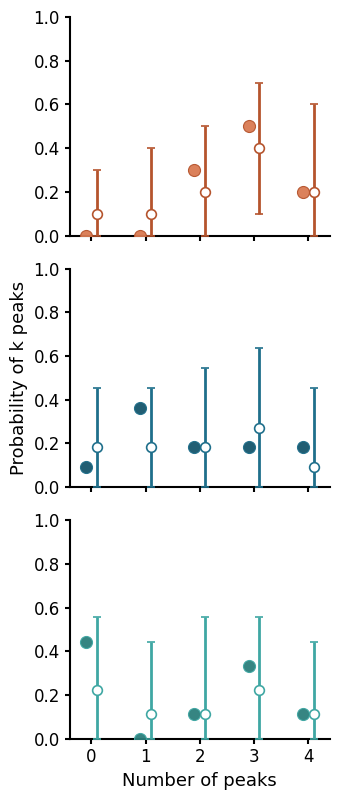

In [69]:
## Plot observed proportions against posterior predictive replicated proportions
fig, axes = plt.subplots(3, 1, figsize=(3.5, 9), sharex=True)

x_offset = 0.1

for ax, lek in zip(axes, lek_labels_ordered):
    empirical_data = peak_proportions[peak_proportions['lek_id'] == lek].sort_values('n_peaks')
    ppc = ppc_summary[ppc_summary['lek_id'] == lek].sort_values('n_peaks')

    col_fill = fill_cols[str(lek)]
    col_point = point_cols[str(lek)]

    # Empirical proportions
    ax.scatter(empirical_data['n_peaks'] - x_offset, empirical_data['prop'], s=75, facecolor=col_point, edgecolor=col_fill,
               linewidth=0.8, alpha=0.95, zorder=4, label="Empirical" if ax is axes[0] else None)

    ## Posterior predictive replicated proportions
    ax.errorbar(ppc['n_peaks'] + x_offset, ppc['median'], yerr=[ppc['median']-ppc['lower'], ppc['upper']-ppc['median']],
                fmt='o', markersize=7, mfc='white', mec=col_fill, mew=1.2, color=col_fill, ecolor=col_fill, elinewidth=2, 
                capsize=3, zorder=3, label='PPC median ± 95% CI' if ax is axes[0] else None)

    ax.set_xticks(peak_categories)
    ax.set_xlim(-0.4, peak_categories.max() + 0.4)
    ax.set_ylim(0, 1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

axes[2].set_xlabel('Number of peaks', fontsize=13)
axes[1].set_ylabel('Probability of k peaks', fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(out_dir/'mod_post_npeaks_structure.png', dpi=300, bbox_inches='tight')

In [55]:
## Specify time axis
t_min, t_max = float(n_peaks_df['t_centred'].min()), float(n_peaks_df['t_centred'].max())
t_grid = np.linspace(t_min, t_max, 200)
t_years = t_grid + n_peaks_df['t_years'].mean()
date_grid = t0 + pd.to_timedelta(t_years * 365.25, unit='D')

In [56]:
def ordered_logistic_probs(eta, c):
    n_draws = eta.shape[0]
    len_time = eta.shape[1]
    n_categories = c.shape[0]+1

    # F_k = logistic(c_k - eta) = P(Y <= k)
    F = 1.0 / (1.0 + np.exp(-(c[:,:,None] - eta[None,:,:])))
    
    p = np.zeros((n_draws, len_time, n_categories))
    p[:,:,0] = F[0]
    for k in range(1, n_categories-1):
        p[:,:,k] = (F[k] - F[k-1])
    p[:,:,n_categories-1] = (1 - F[n_categories-2])
    return p

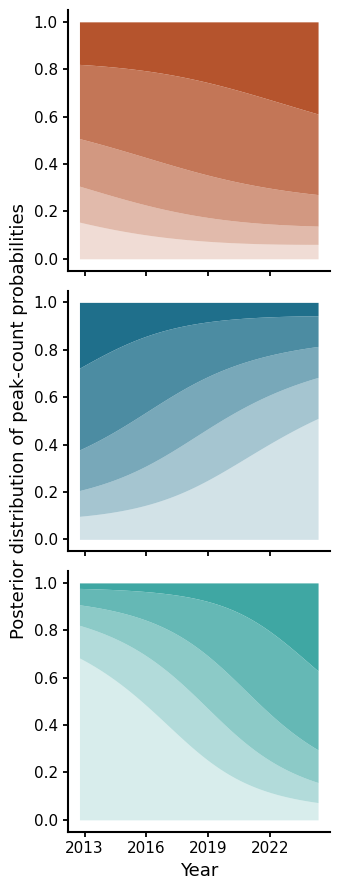

In [63]:
fig,axes = plt.subplots(3, 1, figsize=(3.5, 9), sharex=True)

for ax,lek in zip(axes,lek_labels.values()):
    df_lek = n_peaks_df[n_peaks_df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior predictions of P(y = k) for each site
    eta = fit['alpha'][site_id,:,None] + fit['beta_t'][site_id,:,None] * t_grid[None,:]
    p = ordered_logistic_probs(eta, fit['c'])
    p_mean = p.mean(axis=0)
    n_categories = p_mean.shape[1]

    # Cumulative for stacked area
    cum = np.cumsum(p_mean, axis=1)
    base = np.zeros(len(t_grid))

    for k in range(n_categories):
        top = cum[:,k]
        ax.fill_between(date_grid, base, top, color=fill_cols.get(lek), alpha=0.2 + 0.2*k, linewidth=0)
        base = top

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='both', labelsize=11, width=1.3)

axes[1].set_ylabel('Posterior distribution of peak-count probabilities', fontsize=13)
axes[-1].set_xlabel('Year', fontsize=13)
plt.tight_layout()
plt.savefig(out_dir/'mod_npeaks_time.png', dpi=300, bbox_inches='tight')

In [58]:
for ax,lek in zip(axes,lek_labels.values()):
    df_lek = n_peaks_df[n_peaks_df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior predictions of P(y = k) for each site
    eta = fit['alpha'][site_id,:,None] + fit['beta_t'][site_id,:,None] * t_grid[None,:]
    p = ordered_logistic_probs(eta, fit['c'])
    
    print(f'The median probability of having 2 or more peaks goes up from {np.median(p[:,:,2:].sum(2)[:,0])} to {np.median(p[:,:,2:].sum(2)[:,-1])} for Site{site_id}')
    print(f'The 2.5% quantile probability of having 2 or more peaks goes up from {np.quantile(p[:,:,2:].sum(2)[:,0], 0.025)} to {np.quantile(p[:,:,2:].sum(2)[:,-1], 0.025)} for Site{site_id}')
    print(f'The 97.5% quantile probability of having 2 or more peaks goes up from {np.quantile(p[:,:,2:].sum(2)[:,0], 0.975)} to {np.quantile(p[:,:,2:].sum(2)[:,-1], 0.975)} for Site{site_id}')
    # print(f'The median difference in the probability of having 2 or more peaks was {np.median(p[:,:,2:].sum(2)[:,-1] - p[:,:,2:].sum(2)[:,0])} for Site{site_id}')
    # print(f'The median difference in the probability of having 2 or more peaks was {np.quantile(p[:,:,2:].sum(2)[:,-1] - p[:,:,2:].sum(2)[:,0], 0.025)} for Site{site_id}')
    # print(f'The median difference in the probability of having 2 or more peaks was {np.quantile(p[:,:,2:].sum(2)[:,-1] - p[:,:,2:].sum(2)[:,0], 0.975)} for Site{site_id}')
    print('\n')

The median probability of having 2 or more peaks goes up from 0.7256565418396678 to 0.9039264005182661 for Site0
The 2.5% quantile probability of having 2 or more peaks goes up from 0.2624583539218705 to 0.4996719775282013 for Site0
The 97.5% quantile probability of having 2 or more peaks goes up from 0.9525763191255635 to 0.9897967810564002 for Site0


The median probability of having 2 or more peaks goes up from 0.8347625586308289 to 0.24384399590351324 for Site1
The 2.5% quantile probability of having 2 or more peaks goes up from 0.40157353764736803 to 0.01193370537313862 for Site1
The 97.5% quantile probability of having 2 or more peaks goes up from 0.9773642363941478 to 0.8961294702652958 for Site1


The median probability of having 2 or more peaks goes up from 0.1051053586102792 to 0.8946755990096702 for Site2
The 2.5% quantile probability of having 2 or more peaks goes up from 0.003736930475643141 to 0.4298787597271671 for Site2
The 97.5% quantile probability of having 2 or more

In [32]:
## Assign a unique curve ID for each lek × date
curves_base['curve_id'] = np.arange(1, len(curves_base) + 1, dtype=int)
peaks_only = peaks.dropna(subset=['peak_curvature']).copy()

## Attach curve IDs to each peak row
curvature_df = peaks_only.merge(curves_base[['lek_id', 'date', 'site_id', 'n_points', 'curve_id']], 
                                on=['lek_id', 'date', 'site_id', 'n_points'], how='left', validate='many_to_one')
curvature_df['curve_id'] = pd.factorize(curvature_df['curve_id'])[0] + 1

In [33]:
## Define peak order within each curve
curvature_df = curvature_df.sort_values(['lek_id', 'date', 'r_peak']).reset_index(drop=True)
curvature_df['peak_num'] = curvature_df.groupby(['lek_id', 'date'], observed=False).cumcount() + 1

## Log transform curvature to construct a log-normal model and center peak number
curvature_df['log_curvature'] = np.log(curvature_df['peak_curvature'].astype(float))
curvature_df['peak_num_z'] = curvature_df['peak_num'] - curvature_df['peak_num'].mean()

## Serialise and centre the date / time
t0 = n_peaks_df['date'].min()
curvature_df['t_years'] = (curvature_df['date'] - t0).dt.days / 365.25
curvature_df['t_centred'] = curvature_df['t_years'] - curvature_df['t_years'].mean()

curvature_df = curvature_df[['lek_id', 'site_id', 'date', 'curve_id', 'n_points', 'peak_num', 'peak_num_z', 
                             'r_peak', 's_peak', 't_years', 't_centred', 'peak_curvature', 'log_curvature']]
curvature_df.head()

,lek_id,site_id,date,curve_id,n_points,peak_num,peak_num_z,r_peak,s_peak,t_years,t_centred,peak_curvature,log_curvature
0,TalChhapar_TC,1,2012-10-01,1,162,1,-1.0,23.940216,1.507538,0.000000,-5.578703,11.354952,2.429654
1,TalChhapar_TC,1,2012-10-01,1,162,2,0.0,43.730795,2.753769,0.000000,-5.578703,7.914075,2.068643
2,TalChhapar_TC,1,2012-10-01,1,162,3,1.0,57.775721,3.638191,0.000000,-5.578703,3.606025,1.282606
3,TalChhapar_TC,1,2014-02-01,2,193,1,-1.0,25.029633,1.668342,1.336071,-4.242632,13.886888,2.630945
4,TalChhapar_TC,1,2014-02-01,2,193,2,0.0,39.806164,2.653266,1.336071,-4.242632,12.576464,2.531827


### Model the **total effect** of site-ID and time on the curvature of PCF peaks

In [34]:
curvature_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;

  array[n_points] int<lower=1, upper=n_sites> site_id;

  vector[n_points] t;
  vector[n_points] log_curvature;
}

parameters {
  real alpha;

  vector[n_sites] site_eff_raw;
  real<lower=0> sigma_site;

  vector[n_sites] beta_t;
  
  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] site_eff = site_eff_raw * sigma_site;
}

model {
  // priors
  alpha ~ normal(0, 3);

  site_eff_raw ~ normal(0, 1);
  sigma_site ~ normal(0, 1);

  beta_t ~ normal(0, 1);

  sigma ~ normal(0, 1);

  // likelihood
  for (n in 1:n_points) {
    real mu = alpha + site_eff[site_id[n]] + beta_t[site_id[n]]*t[n];
    log_curvature[n] ~ normal(mu, sigma);
  }
}

generated quantities {
  // site contrasts on log scale
  real diff_T_V1 = site_eff[1] - site_eff[2];
  real diff_T_V2 = site_eff[1] - site_eff[3];
  real diff_V1_V2 = site_eff[2] - site_eff[3];

  // geometric mean ratios on original curvature scale
  real gmr_T_V1 = exp(diff_T_V1);
  real gmr_T_V2 = exp(diff_T_V2);
  real gmr_V1_V2 = exp(diff_V1_V2);
}
"""

In [35]:
data_curvature = {
    'n_points': len(curvature_df),
    'n_sites': int(curvature_df['site_id'].nunique()),
    'site_id': curvature_df['site_id'].astype(int).to_numpy(),
    't': curvature_df['t_centred'].astype(float).to_numpy(),
    'log_curvature': curvature_df['log_curvature'].astype(float).to_numpy(),
}

posterior = stan.build(curvature_mod, data=data_curvature)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:   6% (500/8000)
Sampling:  31% (2500/8000)
Sampling:  56% (4500/8000)
Sampling:  81% (6500/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 5.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.52 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/tmp/httpstan_c5vl1_nb/model_gyutdrto.stan', line 41, column 4 to column 41)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Gradient evaluation took 3.8e-05 seconds
  1000 transitions using 10 leap

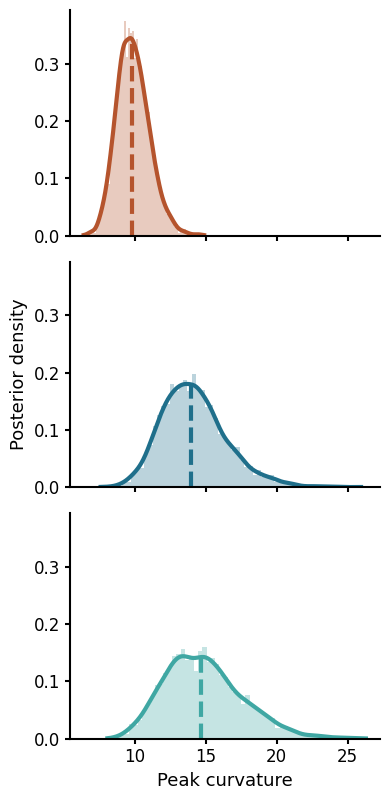

In [36]:
fig, axes = plt.subplots(3, 1, figsize=(4, 9), sharex=True, sharey=True)

for ax, lek in zip(axes, lek_labels.keys()):
    df_lek = curvature_df[curvature_df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior mean log(curvature) and back-transform to return to original units 
    mu = fit['alpha'].reshape(-1, 1) + fit['site_eff'][site_id, :].reshape(-1, 1)
    y = np.exp(mu).ravel()

    # Plot histogram density
    counts, edges = np.histogram(y, bins=60, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)

    ax.bar(centers, counts, width=widths, align='center', alpha=0.3, edgecolor='none', linewidth=0, color=fill_cols[lek_labels[lek]])

    # Add KDE to plot
    xs = np.linspace(edges[0], edges[-1], 600)
    kde = gaussian_kde(y)
    ys = kde(xs)

    ax.plot(xs, ys, linewidth=3, color=fill_cols[lek_labels[lek]])
    ax.vlines(np.median(y), ymin=0, ymax=ys.max(), color=fill_cols[lek_labels[lek]], linewidth=3, linestyle='dashed')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

axes[1].set_ylabel('Posterior density', fontsize=13)
axes[-1].set_xlabel('Peak curvature', fontsize=13)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(out_dir/'mod_peak_curvatures.png', dpi=300, bbox_inches='tight')

In [37]:
## Posterior distributions of latent structure on the leks at mean centred time
site_eff = fit['site_eff']
tal = site_eff[0, :]
vel1 = site_eff[1, :]
vel2 = site_eff[2, :]

## Difference in latent structure between Tal Chhapar and the two Velavadar leks at mean centred time
delta_tv1 = tal - vel1
delta_tv2 = tal - vel2
delta_v1v2 = vel1 - vel2

In [38]:
## Back-transform log curvature to curvature
gmr_tv1 = np.exp(delta_tv1)
gmr_tv2 = np.exp(delta_tv2)
gmr_v1v2 = np.exp(delta_v1v2)

print(f'Peak curvature of Tal Chhapar PCF curves  is {np.median(gmr_tv1)} and {np.median(gmr_tv2)} times than the Velavadar curves respectively')

Peak curvature of Tal Chhapar PCF curves  is 0.701452280204905 and 0.6725428862314464 times than the Velavadar curves respectively


In [39]:
np.quantile(gmr_tv1, 0.025), np.quantile(gmr_tv2, 0.025), np.quantile(gmr_tv1, 0.975), np.quantile(gmr_tv2, 0.975)

(np.float64(0.47200941654965434),
 np.float64(0.43933082344427427),
 np.float64(1.0119313257835019),
 np.float64(1.0118588106139106))